In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# 1. Load Data
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. Drop customer ID
df.drop(columns=['customerID'], inplace=True, errors='ignore')

# 3. Clean TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 4. Map target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 5. One-Hot Encoding (Silences Pandas4Warning)
cat_cols = df.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# 6. Separate Features & Target
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# 7. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 8. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 9. Apply SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Resampled Training Set Shape: {X_train_res.shape}")

Resampled Training Set Shape: (8278, 30)


==================== Logistic Regression ====================
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC Score: 0.8403

==================== Random Forest ====================
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1035
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

ROC-AUC Score: 0.8232

==================== XGBoost ====================
              precision    recall  f1-score   support

           0       0.90      0.79      0.84      1035
           1       0.56

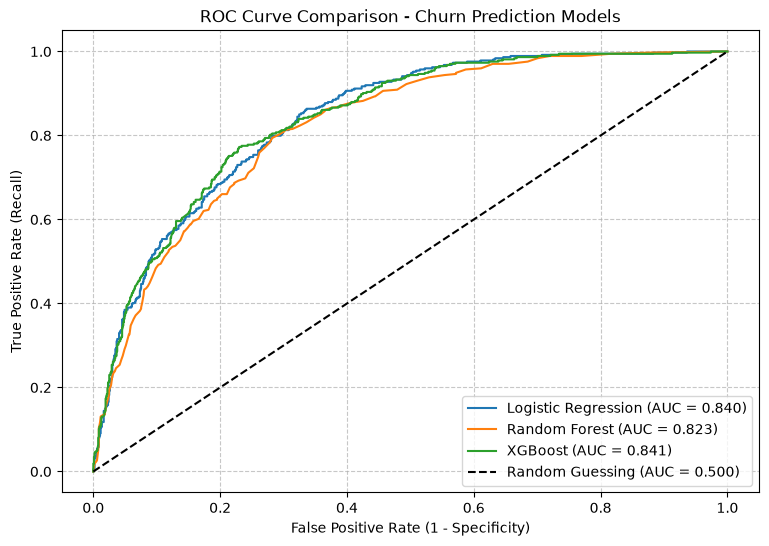

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 1. Initialize Classification Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
}

results = {}

plt.figure(figsize=(9, 6))

# 2. Train and Evaluate Each Model
for name, model in models.items():
    # Train on SMOTE-resampled dataset
    model.fit(X_train_res, y_train_res)
    
    # Predict on unseen original scaled test set
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    auc_score = roc_auc_score(y_test, y_proba)
    results[name] = auc_score
    
    print(f"==================== {name} ====================")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC Score: {auc_score:.4f}\n")
    
    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

# 3. Format ROC Plot
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.500)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison - Churn Prediction Models')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

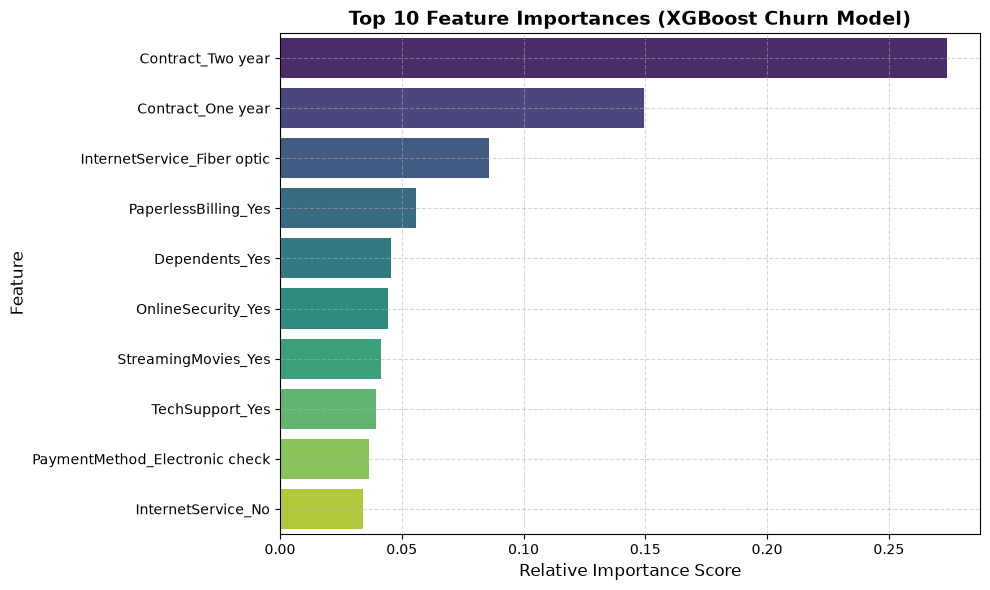

Top 10 Features Driving Customer Churn:
                       Feature  Importance
             Contract_Two year    0.273739
             Contract_One year    0.149507
   InternetService_Fiber optic    0.085777
          PaperlessBilling_Yes    0.055788
                Dependents_Yes    0.045726
            OnlineSecurity_Yes    0.044416
           StreamingMovies_Yes    0.041657
               TechSupport_Yes    0.039370
PaymentMethod_Electronic check    0.036356
            InternetService_No    0.033922


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances from the trained XGBoost model
xgb_model = models["XGBoost"]
importances = xgb_model.feature_importances_

# Create a DataFrame for visual mapping
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot Top 10 Features (Updated for modern Seaborn syntax)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df.head(10),
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)

plt.title('Top 10 Feature Importances (XGBoost Churn Model)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Display Top 10 numeric values
print("Top 10 Features Driving Customer Churn:")
print(feature_importance_df.head(10).to_string(index=False))